# WM-811K 웨이퍼맵 결함 패턴 분류 (CNN) — 6주차 확장, 선택 항목

로드맵에서 "선택적 활용"으로 남겨뒀던 WM-811K 데이터셋으로, 웨이퍼맵 결함 패턴 8종을 분류하는 CNN을 학습한다. 지금까지의 모델(SECOM 표 데이터, 시뮬레이터 시계열)과 달리 **이미지 데이터**를 다루는 세 번째로 독립적인 모델이다.

**데이터 파이프라인 메모**: 원본 `LSWMD.pkl`(2019년, pandas 0.2x대로 피클링)은 이 프로젝트의 메인 pandas(3.x)로는 `pandas.indexes` 모듈을 찾지 못해 직접 읽을 수 없다. 그래서 `scripts/convert_wm811k.py`를 별도 레거시 venv(pandas==1.5.3)로 1회 실행해, 결함 라벨이 있는 웨이퍼(25,519개)만 32x32로 리사이즈(최근접 이웃 — 0/1/2 카테고리 값을 보존)해 `data/processed/wafer_map_defects.npz`로 저장해뒀다. 이 노트북은 그 npz만 읽는다.

**라벨**: 0=다이 없음, 1=정상 다이, 2=결함 다이 (웨이퍼맵 자체가 이미 다이 단위 판정을 담은 카테고리 이미지). 분류 대상은 8개 결함 패턴(Center/Donut/Edge-Loc/Edge-Ring/Loc/Random/Scratch/Near-full) — 'none'(정상 웨이퍼)은 제외했다(로드맵의 "8가지 분류"에 맞춤). 데이터셋에 원래 포함된 Training/Test 분할을 그대로 사용한다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import joblib

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/processed/wafer_map_defects.npz"
MODELS_DIR = "../models"
device = torch.device("cpu")

## 1. 데이터 로드 + EDA

(25519, 32, 32) uint8 [0 1 2]
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


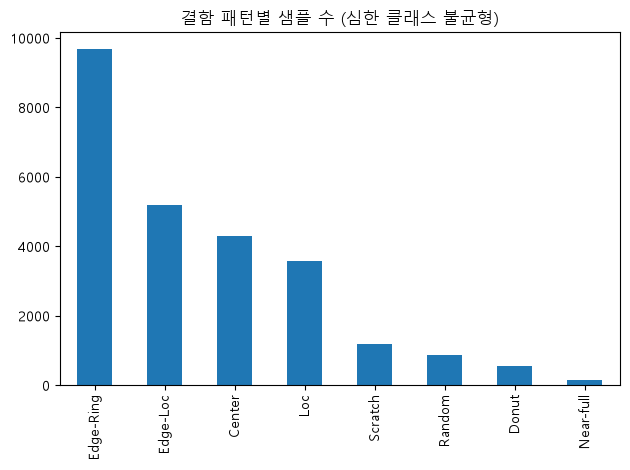

In [2]:
data = np.load(DATA_PATH, allow_pickle=True)
images, labels, split = data["images"], data["labels"], data["split"]
print(images.shape, images.dtype, np.unique(images))

label_counts = pd.Series(labels).value_counts()
print(label_counts)

label_counts.plot(kind="bar", title="결함 패턴별 샘플 수 (심한 클래스 불균형)")
plt.tight_layout()
plt.show()

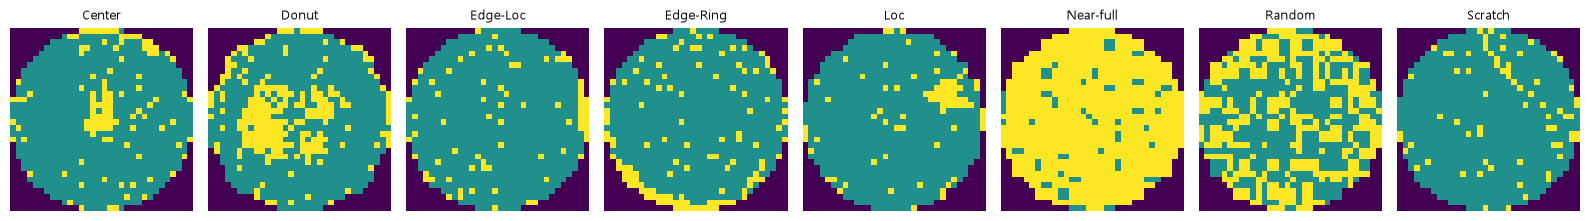

In [3]:
classes = sorted(np.unique(labels))
fig, axes = plt.subplots(1, len(classes), figsize=(2 * len(classes), 2.4))
for ax, cls in zip(axes, classes):
    idx = np.where(labels == cls)[0][0]
    ax.imshow(images[idx], cmap="viridis", vmin=0, vmax=2)
    ax.set_title(cls, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. 전처리

픽셀값 0/1/2를 0~1로 정규화하고 채널 차원을 추가한다. 라벨은 `LabelEncoder`로 정수 인코딩. 데이터셋에 이미 포함된 Training/Test 분할을 그대로 쓴다.

In [4]:
X = (images.astype(np.float32) / 2.0)[:, None, :, :]  # (N, 1, 32, 32)

encoder = LabelEncoder()
y = encoder.fit_transform(labels)
print("classes:", list(encoder.classes_))

train_mask = split == "Training"
test_mask = split == "Test"

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
print("train:", X_train.shape, "test:", X_test.shape)

classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']
train: (17625, 1, 32, 32) test: (7894, 1, 32, 32)


## 3. Dataset / DataLoader + 클래스 가중치

Near-full(149개) vs Edge-Ring(9680개)처럼 최대 65배 차이 나는 불균형이라, `CrossEntropyLoss`에 클래스 역빈도 가중치를 준다(SECOM에서 SMOTE를 썼던 것과 같은 목적, 이미지라 오버샘플링 대신 손실 가중치를 택함).

In [5]:
class WaferMapDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(WaferMapDataset(X_train, y_train), batch_size=128, shuffle=True)
test_loader = DataLoader(WaferMapDataset(X_test, y_test), batch_size=256, shuffle=False)

class_counts = np.bincount(y_train)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * len(class_counts)
print(dict(zip(encoder.classes_, class_weights.tolist())))

{'Center': 0.08873261511325836, 'Donut': 0.7510814666748047, 'Edge-Loc': 0.1270965337753296, 'Edge-Ring': 0.035912126302719116, 'Loc': 0.18962489068508148, 'Near-full': 5.688746452331543, 'Random': 0.5044208765029907, 'Scratch': 0.614384651184082}


## 4. CNN 모델

In [6]:
class WaferMapCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),   # 32->16
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 16->8
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 8->4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = WaferMapCNN(n_classes=len(encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

## 5. 학습

epoch  1/15 — train loss 0.9242


epoch  3/15 — train loss 0.4699


epoch  6/15 — train loss 0.3077


epoch  9/15 — train loss 0.2267


epoch 12/15 — train loss 0.1691


epoch 15/15 — train loss 0.1222


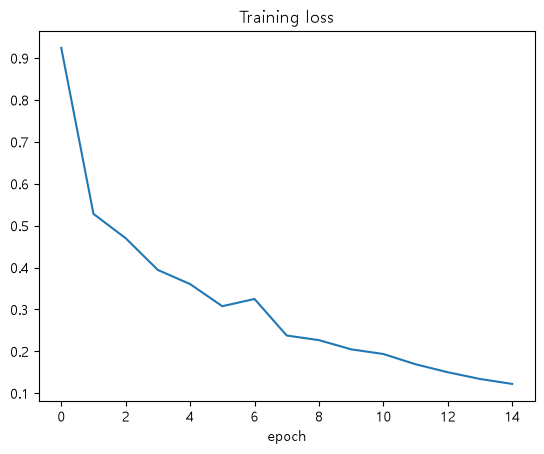

In [7]:
EPOCHS = 15
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(xb)
    train_loss = running_loss / len(X_train)
    history.append(train_loss)
    if epoch % 3 == 0 or epoch == 1:
        print(f"epoch {epoch:>2}/{EPOCHS} — train loss {train_loss:.4f}")

plt.plot(history)
plt.title("Training loss")
plt.xlabel("epoch")
plt.show()

## 6. 평가 (test, 최초 1회)

In [8]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.numpy())
        all_true.append(yb.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

acc = accuracy_score(all_true, all_preds)
macro_f1 = f1_score(all_true, all_preds, average="macro")
print(f"accuracy={acc:.4f}  macro F1={macro_f1:.4f}\n")
print(classification_report(all_true, all_preds, target_names=encoder.classes_))

accuracy=0.6049  macro F1=0.6643

              precision    recall  f1-score   support

      Center       0.73      0.70      0.71       832
       Donut       0.61      0.76      0.67       146
    Edge-Loc       0.80      0.58      0.67      2772
   Edge-Ring       0.84      0.82      0.83      1126
         Loc       0.73      0.38      0.50      1973
   Near-full       0.96      0.81      0.88        95
      Random       0.60      0.88      0.71       257
     Scratch       0.22      0.75      0.34       693

    accuracy                           0.60      7894
   macro avg       0.69      0.71      0.66      7894
weighted avg       0.72      0.60      0.63      7894



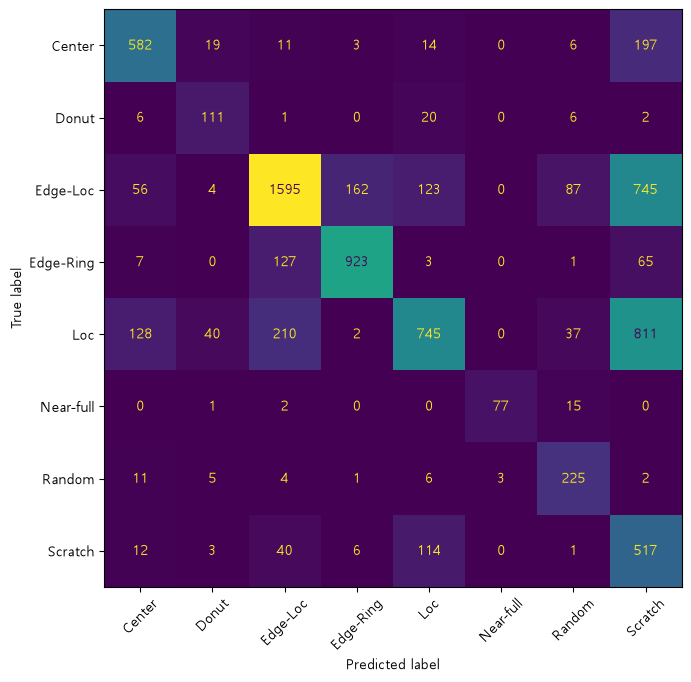

In [9]:
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=encoder.classes_).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()

## 7. 저장

In [10]:
import os
os.makedirs(MODELS_DIR, exist_ok=True)

torch.save(model.state_dict(), f"{MODELS_DIR}/wafer_map_cnn.pt")
joblib.dump(list(encoder.classes_), f"{MODELS_DIR}/wafer_map_classes.joblib")

per_class = pd.DataFrame(
    classification_report(all_true, all_preds, target_names=encoder.classes_, output_dict=True)
).T
per_class.to_csv(f"{MODELS_DIR}/wafer_map_cnn_report.csv")

print("저장 완료")
print(f"test accuracy={acc:.4f}, macro F1={macro_f1:.4f}")

저장 완료
test accuracy=0.6049, macro F1=0.6643


## 결론

실행 결과(위 classification report)를 보고 채운다. 이 모델은 SECOM(표 데이터)·시뮬레이터(시계열)와 완전히 다른 네 번째 데이터 모달리티(이미지)를 다뤄, "표 데이터뿐 아니라 이미지 데이터도 다뤄봤다"는 걸 보여주는 게 목적이다. `backend`/`frontend`에는 연동하지 않았다 — LSTM Autoencoder와 마찬가지로 로드맵상 노트북 수준 실험으로 범위를 한정.